# 10 — NIST Cybersecurity Training Dataset (`ethanolivertroy/nist-cybersecurity-training`)

## 1. ¿De qué trata este dataset?
Es el conjunto de datos de entrenamiento abierto más grande en Hugging Face para instruir a modelos de lenguaje en las normativas y marcos del **NIST** (*National Institute of Standards and Technology*).

* **Volumen:** **≈530.912 ejemplos** en formato conversacional nativo (`messages`: `system`, `user`, `assistant`) repartidos en `train.jsonl` (80%) y `valid.jsonl` (20%).
* **Fuente exhaustiva:** Extraído y normalizado a partir de **596 publicaciones oficiales del NIST**, incluyendo:
  * **SP (Special Publications):** Series 800 y 1800 (ej. SP 800-53 de Controles de Seguridad, SP 800-207 de Zero Trust, SP 800-61 de Manejo de Incidentes).
  * **FIPS:** Estándares federales de criptografía y procesamiento de información (ej. FIPS 140-3).
  * **CSWP (Cybersecurity White Papers):** Incluye la versión reciente del **NIST CSF 2.0**, criptografía post-cuántica y directrices de IoT.
  * **IR:** Reportes interinstitucionales técnicos.
* **Tipos de contenido:** Secciones completas de documentos (263k), fragmentos semánticos (136k), especificaciones de controles de seguridad (88k) y definiciones técnicas (43k).
* **Embeddings opcionales:** Incluye vectores precomputados de 1536 dimensiones (`text-embedding-3-small`) con índices FAISS para aplicaciones RAG inmediatas.

---

## 2. ¿Con qué propósito se construyó?
* **Resolver las alucinaciones en cumplimiento normativo:** Los marcos del NIST son la base legal y técnica del gobierno de EE. UU. (FedRAMP, FISMA), banca e infraestructura crítica global. Sin embargo, los documentos oficiales son miles de páginas en PDF con terminología densa donde los LLMs genéricos suelen inventar identificadores de controles o mezclar versiones desactualizadas.
* **Democratizar la auditoría técnica:** Proveer un corpus limpio y curado (con más de 120.000 enlaces y DOIs normalizados) para convertir modelos de propósito general en especialistas autoritativos en gobernanza, riesgo y cumplimiento (GRC).

---

## 3. ¿En qué aporta y en qué se puede usar?
### Aportes clave
* **Taxonomía oficial estructurada:** Controles explícitos catalogados por familias (AC - Access Control, IA - Identification & Authentication, SC - System & Communications Protection, etc.).
* **Doble modalidad de uso:** Listo tanto para entrenamiento directo (*Supervised Fine-Tuning*) como para recuperación vectorial contextual (*RAG*).
* **Formato Chat estandarizado:** Compatible directamente con pipelines modernos de entrenamiento de OpenAI, Hugging Face `transformers` y Apple `mlx`.

### Casos de uso
1. **Copiloto de Cumplimiento y Auditoría (GRC):** Responder con citas normativas precisas qué directrices exige la ley para almacenamiento en nube o autenticación multifactor.
2. **Asistente de Arquitectura Segura:** Guía paso a paso para implementar principios de **Zero Trust Architecture** (SP 800-207).
3. **Mapeo de vulnerabilidades a controles:** Indicar qué control compensatorio de NIST SP 800-53 mitiga un hallazgo descubierto en un pentest o escaneo de CVEs.

---

## 4. ¿Qué modelos se pueden entrenar? ¿Son agentes o son LLMs con LLaMA?
Este dataset está diseñado para el **[Nivel 4] (LLMs Asistenciales con RAG)** y **[Nivel 3] (Modelos Instructivos de Ciberseguridad)**:

* **¿Son LLMs con LLaMA? SÍ:**
  * Modelos de pesos abiertos como **LLaMA 3 (8B / 70B)**, **Qwen 2.5 (7B / 14B / 32B)** o **Mistral (7B)**.
  * Se entrenan mediante **Supervised Fine-Tuning (SFT / LoRA / QLoRA)** para que el modelo adquiera la jerga técnica, reconozca los códigos de control (`AC-2`, `IA-5`, `SC-7`) y aprenda a responder con la precisión de un auditor de seguridad.
* **¿Son agentes? NO directamente, pero sirven como el "Cerebro Experto":**
  * El dataset entrena al modelo de lenguaje.
  * En un sistema agéntico (Nivel 5), el agente que analiza la configuración de un clúster de Kubernetes o una cuenta de AWS consulta a este LLM especializado para saber si la configuración cumple o viola las políticas del NIST.
* **Estrategia óptima (Fine-Tuning + RAG):**
  * El **Fine-Tuning** entrena la lógica, el razonamiento y la terminología del auditor.
  * El **RAG** (usando los embeddings y textos del dataset) inyecta la cita textual exacta del párrafo normativo sin riesgo de desactualización.

---

## 5. ¿Cómo quedaría funcionando en un sistema real?


1. **Escaneo continuo:** Herramientas de postura de seguridad (CSPM / Trivy / CloudTrail) detectan configuraciones erróneas en los sistemas.
2. **Evaluación experta:** El microservicio consulta al LLM instruido con el dataset NIST para contrastar el estado actual contra el estándar federal requerido.
3. **Informe accionable:** El modelo redacta la no-conformidad citando el control exacto del NIST y genera el bloque de código de remediación para los ingenieros de infraestructura.


In [2]:
import sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Busca la raíz del repo (donde está src/profiler.py) y la agrega al path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "profiler.py").exists())
sys.path.insert(0, str(ROOT))
from src.profiler import *

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

ctx = eda_context("10")   # rutas: datos en data/raw/..., resultados en esta carpeta
print(ctx)

Repo:     C:\Users\ameir\repositories\hf-security-study
Datos:    C:\Users\ameir\repositories\hf-security-study\data\raw\top10_security\10_ethanolivertroy__nist-cybersecurity-training
Salidas:  C:\Users\ameir\repositories\hf-security-study\eda\10_nist_cybersecurity  (figures/, tables/)


## 1. Inventario (sin la carpeta de embeddings)

In [3]:
files = list_files(ctx.data_dir)
display(files[~files["archivo"].str.startswith("embeddings/")])
print("Embeddings (no se cargan):", round(files[files["archivo"].str.startswith("embeddings/")]["size_mb"].sum() / 1e3, 2), "GB")
for f in ["data_stats.json", "embeddings/embedding_summary.json"]:
    p = ctx.data_dir / f
    if p.exists():
        print(f"\n{f}:"); print(json.dumps(read_json_any(p), indent=2))

,archivo,ext,size_mb
3,train.jsonl,.jsonl,802.537
5,valid.jsonl,.jsonl,200.689
6,README.md,.md,0.007
7,.gitattributes,,0.003
8,data_stats.json,.json,0.000


Embeddings (no se cargan): 10.17 GB

data_stats.json:
{
  "total_examples": 530912,
  "train_examples": 424729,
  "validation_examples": 106183,
  "train_split": 0.8,
  "source_documents": 1193,
  "chunking_enabled": true,
  "max_chunk_size": 2000
}

embeddings/embedding_summary.json:
{
  "total_examples": 530912,
  "train_examples": 424729,
  "valid_examples": 106183,
  "embeddings_generated": 530912,
  "total_tokens": 174839482,
  "total_cost": 3.4967896400000003,
  "model": "text-embedding-3-small",
  "embedding_dim": 1536
}


## 2. Cargar muestras de train y valid
Los archivos pesan ~800 MB y ~200 MB: se toma una muestra aleatoria.

In [4]:
SAMPLE_N = 30_000

def parse_nist(d):
    """Convierte messages/metadata en columnas planas."""
    out = pd.DataFrame({
        role: d["messages"].apply(lambda ms: next((m.get("content") for m in ms if m.get("role") == role), None))
        for role in ["system", "user", "assistant"]
    })
    meta = pd.json_normalize(d["metadata"].apply(lambda x: x if isinstance(x, dict) else {}))
    return pd.concat([out, meta], axis=1)

print("Primer registro:"); display(peek_record(ctx.data_dir / "train.jsonl"))
N_TRAIN = count_lines(ctx.data_dir / "train.jsonl")
N_VALID = count_lines(ctx.data_dir / "valid.jsonl")
print(f"train: {N_TRAIN:,} | valid: {N_VALID:,}")

df = parse_nist(read_jsonl(ctx.data_dir / "train.jsonl", sample=SAMPLE_N))
dv = parse_nist(read_jsonl(ctx.data_dir / "valid.jsonl", sample=SAMPLE_N // 4))
print(df.shape, dv.shape)
display(df.head(3))
display(profile_df(df))

Primer registro:


{'messages': "[{'role': 'system', 'content': 'You are a cybersecurity expert with deep knowledge of NIST standards, frameworks, and best practices. You provide accurate, detailed guidance on cybersecurity controls, risk management, cloud security, and compliance based on NIST publications including the 800 series…",
 'metadata': "{'source': 'Security Content Automation Protocol (SCAP) Version 1.2 Validation Program Test Requirements', 'type': 'semantic_chunk', 'chunk_id': 2}"}

train: 424,729 | valid: 106,183
(30000, 6) (7500, 6)


,system,user,assistant,source,type,chunk_id
0,"You are a cybersecurity expert with deep knowledge of NIST standards, frameworks, and best practices. You provide ac...",What information does Guidelines for Smart Grid Cybersecurity provide? (Section 212),Moderate: SG.SA-1 High: SG.SA-1 SG.SA-2 Security Policies for Contractors and Third Parties Category: Common Governa...,Guidelines for Smart Grid Cybersecurity,semantic_chunk,211.0
1,"You are a cybersecurity expert with deep knowledge of NIST standards, frameworks, and best practices. You provide ac...",What is control HA-1 in Securing Web Transactions_ TLS Server Certificate Management? (Part 18),"Control HA-1: es, it is important to not inundate certificate owners with notifications, as they will likely start t...",Securing Web Transactions_ TLS Server Certificate Management,control,17.0
2,"You are a cybersecurity expert with deep knowledge of NIST standards, frameworks, and best practices. You provide ac...",What does Preliminary Functional Specifications of a Prototype Electronic Research Notebook for NIST say about Messa...,"According to Preliminary Functional Specifications of a Prototype Electronic Research Notebook for NIST, Message sen...",Preliminary Functional Specifications of a Prototype Electronic Research Notebook for NIST,section,0.0


,dtype,nulos,%nulos,vacíos,únicos,len_media,len_mediana,len_max
columna,,,,,,,,
system,object,0,0.00,0,1,298.0,298.0,298.0
user,object,0,0.00,0,26849,122.2,116.0,1547.0
assistant,object,0,0.00,0,28317,1201.5,1302.0,6153.0
source,object,0,0.00,0,592,72.1,67.0,150.0
type,object,0,0.00,0,4,9.1,7.0,14.0
chunk_id,float64,3033,10.11,0,755,NaN,NaN,NaN


## 3. Tipos y publicaciones fuente

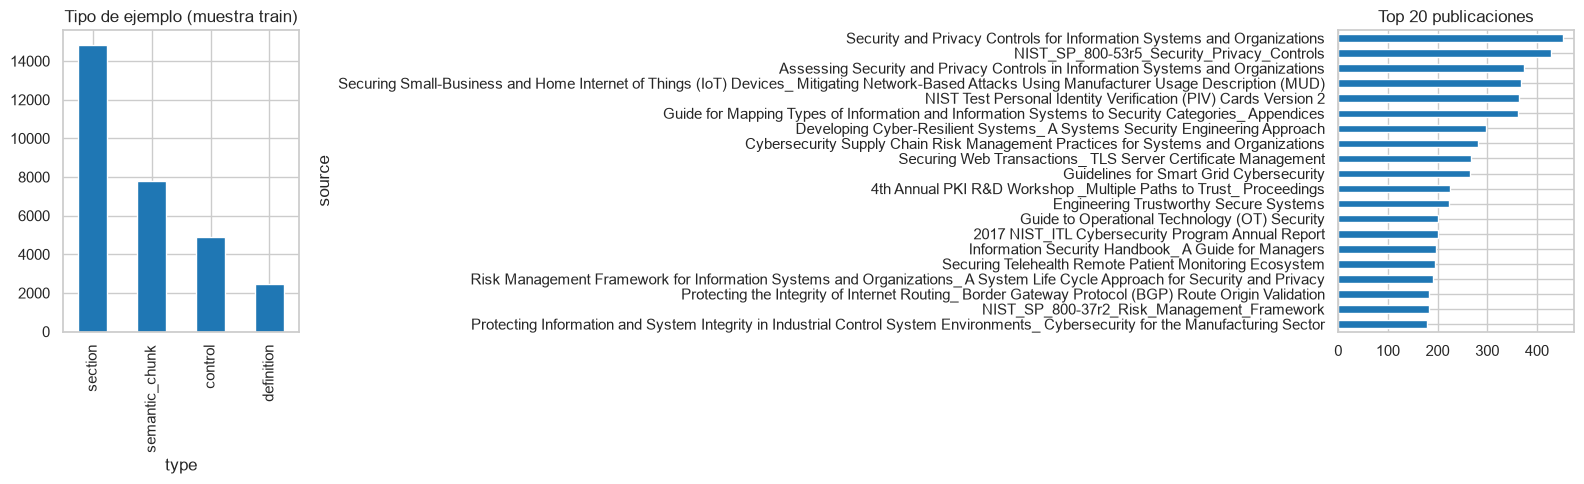

Publicaciones distintas en la muestra: 592


,n
0,
Test,363
Big,147
Cloud,61
Cybersecurity,39
Privacy,35
Roadmap,21
Cryptographic,19
Workshop,12
Risk,9


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df["type"].value_counts().plot.bar(ax=axes[0]); axes[0].set_title("Tipo de ejemplo (muestra train)")
df["source"].value_counts().head(20).plot.barh(ax=axes[1]); axes[1].invert_yaxis(); axes[1].set_title("Top 20 publicaciones")
plt.tight_layout(); save_fig(fig, ctx, "tipos_y_fuentes"); plt.show()
print("Publicaciones distintas en la muestra:", df["source"].nunique())

serie = df["source"].str.extract(r"^NIST\s+(\w+)")[0]
display(serie.value_counts().to_frame("n"))

## 4. Largo del contenido

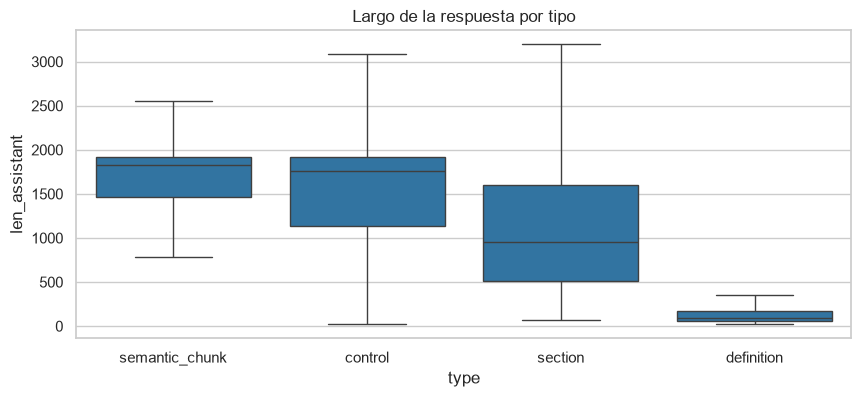

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
control,4897.0,1454.0,639.0,23.0,1141.0,1759.0,1917.0,4735.0
definition,2457.0,165.0,197.0,21.0,61.0,92.0,177.0,2037.0
section,14840.0,1061.0,637.0,73.0,510.0,952.0,1605.0,5643.0
semantic_chunk,7806.0,1637.0,466.0,33.0,1468.0,1823.0,1922.0,6153.0


In [6]:
df["len_assistant"] = df["assistant"].fillna("").str.len()
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="type", y="len_assistant", showfliers=False, ax=ax); ax.set_title("Largo de la respuesta por tipo")
save_fig(fig, ctx, "largo_por_tipo"); plt.show()
display(df.groupby("type")["len_assistant"].describe().round(0))
df = df.drop(columns=["len_assistant"])

## 5. Duplicados y fuga train/valid

In [7]:
display(duplicates_report(df, {"user": ["user"], "assistant": ["assistant"], "user + assistant": ["user", "assistant"]}))
print("System prompts distintos:", df["system"].nunique())
display(df["user"].str.split().str[:4].str.join(" ").value_counts().head(15).to_frame("n"))

ht, hv = set(df["assistant"].map(text_hash)), set(dv["assistant"].map(text_hash))
print(f"Respuestas de la muestra de valid presentes en la muestra de train: {len(ht & hv)} de {len(hv)}")
print("(Es una cota inferior: con muestras solo se detecta parte del solapamiento real)")

,duplicados,%
criterio,,
user,3151,10.50
assistant,1683,5.61
user + assistant,1043,3.48


System prompts distintos: 1


,n
user,
What information does Guide,577
What does Computer Security,461
What information does Guidelines,454
What does Guide to,438
What information does Securing,379
What does Recommendation for,373
What information does Security,355
What is control ES-1,345
What information does Computer,335


Respuestas de la muestra de valid presentes en la muestra de train: 775 de 7368
(Es una cota inferior: con muestras solo se detecta parte del solapamiento real)


In [8]:
show_examples(df, n=3, cols=["source", "type", "user", "assistant"], max_chars=600)

fila 8225
--- source ---
A Framework for Designing Cryptographic Key Management Systems
--- type ---
definition
--- user ---
What is FR according to A Framework for Designing Cryptographic Key Management Systems?
--- assistant ---
FR: 4.26 The CKMS design shall specify if and how its key and/or metadata management functions may be configured to support differing domain security policies and differing applications.
fila 10794
--- source ---
Computer Security Division 2005 Annual Report
--- type ---
section
--- user ---
What does Computer Security Division 2005 Annual Report say about Return on Security Investment?
--- assistant ---
According to Computer Security Division 2005 Annual Report, Return on Security Investment: One of our goals is to develop modeling tools for the Federal community to help them select cost-effective strategies to achieve a level of computer security commensurate with the degree of risk and magnitude of likely harm. We are interested in doing some more research